# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Разработка A/B-тестирования и анализ результатов




## Цели и задачи проекта



Цель проекта: Выяснить, верна ли гипотеза о том, что в Санкт-Петербурге в среднем больше времени проводят за прослушиванием книг, чем в Москве. Написать аналитическую записку.




## Описание данных

Содержание таблицы `yandex_knigi_data.csv` - данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности.
Поля таблицы:
- `city` — город пользователя;
- `puid	` - идентификатор пользователя;
- `hours` - сумма часов активности прослушивания книг пользователя


## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Проверка гипотезы.
4. Результаты анализа
5. Итоговые выводы.



## 1. Загрузка данных и знакомство с ними


In [ ]:
# Импортируем библиотеки
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

from statsmodels.stats.proportion import proportions_ztest

# Выгружаем данные в переменную
books_df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)
books_df.head(10)

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434
5,Москва,352567,8.206369
6,Москва,439493,0.857758
7,Москва,494541,0.035072
8,Москва,647235,12.000076
9,Москва,656480,0.973032


### 2. Предобработка данных двух выборок


In [ ]:
books_df.shape

(8784, 3)

In [ ]:
#проверим на дубликаты в идентификаторах
group_a = books_df[books_df['city'] == 'Москва']['puid']
group_b = books_df[books_df['city'] == 'Санкт-Петербург']['puid']


intersection = list(set(group_a) & set(group_b))
print(intersection)

#группы пересекаются

[439054848, 98068993, 84978689, 331188228, 59679749, 790564870, 40698887, 162106378, 1078819852, 1684058125, 1130000018954257, 959563282, 571554323, 1358054932, 313990163, 1778617878, 1210363415, 1316543509, 649885721, 1183963675, 1395494429, 1314529823, 1145886241, 1593760291, 1725564965, 24138278, 520518182, 363351088, 108083761, 570189363, 584447544, 860187201, 309104707, 550835780, 441112643, 1977784899, 1406501962, 528250442, 103543372, 1616171597, 589188176, 989693522, 1958805587, 401065555, 1557916755, 429727314, 1130000028554332, 488154206, 1965288031, 10597984, 9979490, 301108324, 1607495785, 767485035, 453988975, 912829040, 955554416, 1672056947, 819309176, 10815097, 196683896, 1076879993, 1974615673, 531369086, 1011254911, 555866239, 258809476, 66998918, 360290950, 1085783174, 236601993, 359740041, 998045836, 888840333, 2019864206, 1109631631, 1713008273, 317826707, 1236880533, 46837910, 1166679702, 137198745, 1891219106, 987817124, 1735154341, 176447657, 1748029097, 3793466

In [ ]:
books_dublicated = books_df[books_df['puid'].isin(intersection)].sort_values(by=['puid'])
#доля таких повторений = 5.5 %
100*len(books_dublicated)/books_df['puid'].shape[0]

5.555555555555555

In [ ]:
#Удалим повторяющиеся айди пользователей из двух групп, чтобы группы стали независимыми.
books_final = books_df[~books_df['puid'].isin(intersection)]

In [ ]:
#Проверка на дубли по айди = 0
books_final.duplicated(subset=['puid']).sum()

0

In [ ]:
books_final['city'].value_counts()

Москва             5990
Санкт-Петербург    2306
Name: city, dtype: int64

In [ ]:
#визуально различие ощутимое между количеством пользователей в группах
#72% в Москве, 28 % в Санкт-петербурге
100 * books_final[books_final['city'] == 'Москва']['puid'].nunique() / books_final['puid'].nunique(), 100 * books_final[books_final['city'] == 'Санкт-Петербург']['puid'].nunique() / books_final['puid'].nunique()


(72.20347155255544, 27.79652844744455)

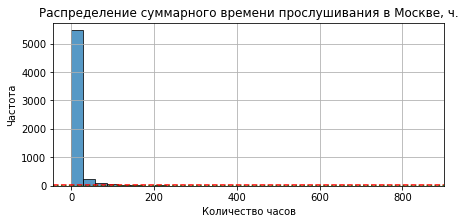

In [ ]:
#посчитаем статистики, рассмотрим выбросы и распределение групп Москвы
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
books_final[books_final['city'] == 'Москва']['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение суммарного времени прослушивания в Москве, ч.')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем линию среднего значения
plt.axhline(y=books_final[books_final['city'] == 'Москва']['hours'].mean(), color='red', linestyle='--')

# Добавляем линию медианы
plt.axhline(y=books_final[books_final['city'] == 'Москва']['hours'].median(), color='green', linestyle=':')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

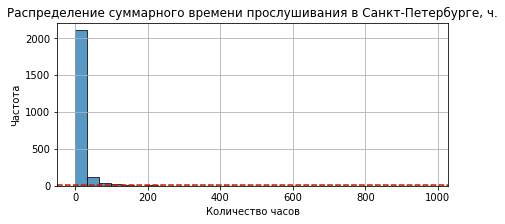

In [ ]:
#посчитаем статистики, рассмотрим выбросы и распределение групп Спб
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
books_final[books_final['city'] == 'Санкт-Петербург']['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение суммарного времени прослушивания в Санкт-Петербурге, ч.')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Добавляем линию среднего значения
plt.axhline(y=books_final[books_final['city'] == 'Санкт-Петербург']['hours'].mean(), color='red', linestyle='--')

# Добавляем линию медианы
plt.axhline(y=books_final[books_final['city'] == 'Санкт-Петербург']['hours'].median(), color='green', linestyle=':')

# Выводим график
plt.show()

Действительно, есть выбросы. Оставим значения, которые будут меньше 99%-го процентиля этого ряда значений или равны ему.

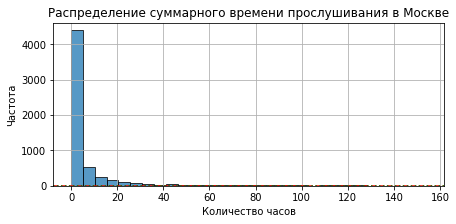

In [ ]:
books_moscow = books_final[books_final['city'] == 'Москва']
books_moscow_fnl = books_moscow[books_moscow['hours'] <= books_moscow['hours'].quantile(0.99)]

plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
books_moscow_fnl['hours'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение суммарного времени прослушивания в Москве')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Добавляем линию среднего значения
plt.axhline(y=books_moscow_fnl['hours'].mean(), color='red', linestyle='--')

# Добавляем линию медианы
plt.axhline(y=books_moscow_fnl['hours'].median(), color='green', linestyle=':')


# Выводим график
plt.show()

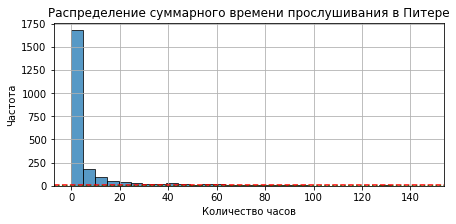

In [ ]:
books_spb = books_final[books_final['city'] == 'Санкт-Петербург']
books_spb_fnl = books_spb[books_spb['hours'] <= books_spb['hours'].quantile(0.99)]

plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
books_spb_fnl['hours'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение суммарного времени прослушивания в Питере')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Добавляем линию среднего значения
plt.axhline(y=books_spb_fnl['hours'].mean(), color='red', linestyle='--')

# Добавляем линию медианы
plt.axhline(y=books_spb_fnl['hours'].median(), color='green', linestyle=':')

# Выводим график
plt.show()

После удаления выбросов разница между двумя группами не изменилась.

In [ ]:
books_for_test=books_final[books_final['hours'] <= books_final['hours'].quantile(0.95)]
books_for_test['city'].value_counts()
#72% в Москве, 28 % в Санкт-петербурге
100 * books_for_test[books_for_test['city'] == 'Москва']['puid'].nunique() / books_for_test['puid'].nunique(), 100 * books_for_test[books_for_test['city'] == 'Санкт-Петербург']['puid'].nunique() / books_final['puid'].nunique()


(72.2243370130694, 26.386210221793636)

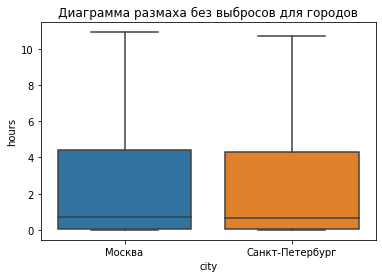

In [ ]:
sns.boxplot(data=books_for_test, x='city', y='hours', showfliers=False)
plt.title('Диаграмма размаха без выбросов для городов')
plt.show()

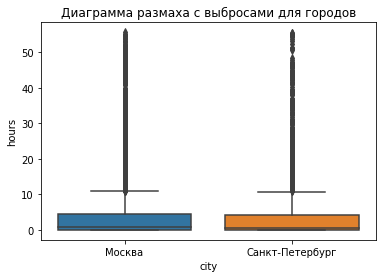

In [ ]:
sns.boxplot(data=books_for_test, x='city', y='hours', showfliers=True)
plt.title('Диаграмма размаха с выбросами для городов')
plt.show()

Посмотрим статистические параметры двух групп

In [ ]:
books_for_test[books_for_test['city'] == 'Москва'].describe()

,puid,hours
count,5.692000e+03,5692.000000
mean,1.052269e+13,4.641440
std,1.085401e+14,9.065174
min,9.668000e+03,0.000022
25%,3.230278e+08,0.047265
50%,8.826046e+08,0.721415
75%,1.528257e+09,4.397664
max,1.130000e+15,55.577836


In [ ]:
books_for_test[books_for_test['city'] == 'Санкт-Петербург'].describe()

,puid,hours
count,1.726000e+03,1726.000000
mean,5.238525e+12,0.984869
std,7.677498e+13,1.412063
min,1.464270e+05,0.000025
25%,4.048341e+08,0.022408
50%,9.888624e+08,0.290403
75%,1.562449e+09,1.316897
max,1.130000e+15,5.927015


Группы сопоставимы по ключевой метрике (hours), а именно, медиана, среднее, среднеквадратичное отклонение – можно проводить A/B-тест без серьезных искажений.
Разница в размере групп (72% vs 28%) не критична, так как распределения похожи.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [ ]:
metric_a = books_for_test[books_for_test.city == 'Москва']['hours']
metric_b = books_for_test[books_for_test.city == 'Санкт-Петербург']['hours']

In [ ]:
#Проверим дисперсию у обоих групп
stat, p = stats.bartlett(metric_a, metric_b)

if p < 0.05:
    print("Дисперсии значимо различаются - используем тест Уэлча")
else:
    print("Дисперсии не различаются - можно использовать t-test Стьюдента")

Дисперсии значимо различаются - используем тест Уэлча


In [ ]:
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a,
    metric_b,
    equal_var=False,
    alternative='less' ## поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки (metric_a) меньше второй выборки
) ## применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны, и в группе B больше')
    print('Интерпретация: перевод интерфейса маркетплейса увеличил количество просматриваемых страниц в рамках сессии')

p-value теста Уэлча =0.09
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии


In [ ]:
alpha = 0.05 #уровень значимости

stat_ttest, p_value_ttest = ttest_ind(
    metric_a,
    metric_b,
    alternative='less' #проверяем , что выборочное среднее первой выборки меньше второй
)
if p_value_ttest>alpha:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Среднее время прослушивания книг в группах A и B равны')
else:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Среднее время прослушивания книг в группах A и B не равны, и в группе B больше')


p-value теста Стьюдента =0.75
Нулевая гипотеза находит подтверждение! Среднее время прослушивания книг в группах A и B равны


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



Для сравнения среднего времени прослушивания книг между группами A и B был применен t-тест Стьюдента  с равными дисперсиями.

Уровень статистической значимости (alpha): 0.05
Нулевая гипотеза (H0): Среднее время прослушивания книг в группах A и B равно.
Альтернативная гипотеза (H1): Среднее время прослушивания книг в группах A и B различается.

Результаты теста: p-value: 0.26

Вывод:
Если p-value ≤ alpha, отвергаем H₀.
Если p-value > alpha, не отвергаем H₀.
Нулевая гипотеза находит подтверждение! Среднее время прослушивания книг в группах A и B равны.

Причины: Действительно нет разницы в среднем времени в группах А и Б, либо можно увеличить группу Б и провести еще один тест.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Опишите цели исследования.



Известно, что текущий интерфейс сайта слишком сложен для пользователя. Разработана новая версия сайта, протестирована на части пользователей. Цель исследования - оценить результаты А/В теста `interface_eu_test`.

В техническом задании от аналитика альтернативная гипотеза следующая: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

## 2. Загрузите данные, оцените их целостность.


In [ ]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [ ]:
participants.head(5)

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [ ]:
events.head(5)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [ ]:
# Выводим информацию о датафрейме
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В датафрейме `participants` пропусков нет, всего 14525 строк. В `events` в три раза меньше записей в столбце `details`, это столбец с дополнительной информацией, включая покупки.

In [ ]:
#найдены явные дубликаты в таблице events
events.duplicated().sum()

36318

- Удалим их
- посмотрим на дубли, связанные со временем

In [ ]:
#удаляем полные дубли
events_df = events.drop_duplicates().reset_index(drop=True)

Присутствуют дубли в сочетании user_id + время, но это включая login + registration, что логично. Это происходит мгновенно. Оставляем как есть

In [ ]:
events_df.shape

(750968, 4)

In [ ]:
print(f"Период данных: {events['event_dt'].min()} - {events['event_dt'].max()}")

Период данных: 2020-12-01 00:00:00 - 2020-12-31 23:59:48


## 3. По таблице `ab_test_participants` оцените корректность проведения теста:


In [ ]:
#выделим участников теста `interface_eu_test`
participants_needed = participants[participants['ab_test'] == 'interface_eu_test']
participants_needed['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

В группах есть незначительное расхождение по кол-ву участников, проверим на пересечение

In [ ]:
#проверим на дубликаты в идентификаторах
all_group = participants_needed.groupby('user_id')['group'].nunique()
all_group[all_group == 2].index.tolist()
#группы не пересекаются

[]

In [ ]:
participants['ab_test'].unique()

array(['interface_eu_test', 'recommender_system_test'], dtype=object)

In [ ]:
#выделим участников теста `recommender_system_test`
participants_recommender = participants[participants['ab_test'] == 'recommender_system_test']
participants_recommender['group'].value_counts()

A    2747
B     928
Name: group, dtype: int64

In [ ]:
#проверим пересечение пользователей в двух конкурирующих тестах interface_eu_test и recommender_system_test

group_a = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
group_b = participants[participants['ab_test'] == 'recommender_system_test']['user_id']


intersection = list(set(group_a) & set(group_b))
print(len(intersection))

#группы пересекаются, 887 user совпадают с исследуемым тестом interface_eu_test

887


Поскольку два теста будут использоваться для проверки гипотез, важно, чтобы пользователи не пересекались. Чтобы была чистота эксперимента, статистическая независимость, пользователь мог среагировать на новый дизайн хуже/лучше после того, как увидел новую рекомендательную систему, нивелируем этот эффект.

In [ ]:
#удалим повторяющихся юзеров
df_participants = participants_needed[~participants_needed['user_id'].isin(intersection)]
df_participants['group'].value_counts()

B    5011
A    4952
Name: group, dtype: int64

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:


По техническому заданию нас интересует момент регистрации пользователя, событие `registration` и момент покупки `purchase`

In [ ]:
#events_df['event_name'].unique()

In [ ]:
events_filter = events_df[(events_df['event_name'] == 'registration') | (events_df['event_name'] == 'purchase')]

In [ ]:
events_filter.shape

(244902, 4)

In [ ]:
#соединим две таблицы с результататами А/Б теста

df_merged = pd.merge(
    df_participants,
    events_filter,
    on='user_id',
    how='left'
)

df_merged.shape

(18864, 7)

In [ ]:
df_merged.head(3)

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61
2,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [ ]:
#добавим столбец с регистрацией и объединим как новый столбец к исходному events_filter
reg_dates = df_merged[df_merged['event_name'] == 'registration'][['user_id', 'event_dt']].rename(columns={'event_dt': 'reg_date'})

events_with_time = pd.merge(
    df_merged,
    reg_dates,
    on='user_id',
    how='left'
)

In [ ]:
#20 441 событий
events_with_time.shape

(18864, 8)

In [ ]:
events_with_time['event_name'].unique()

array(['registration', 'purchase'], dtype=object)

In [ ]:
# Вычисляем разницу в днях
events_with_time['days_after'] = (events_with_time['event_dt'] - events_with_time['reg_date']).dt.days

In [ ]:
#Фильтруем с условием больше 0 и не менее 7 дней после регистрации
events_7days = events_with_time[(events_with_time['days_after'] >= 0)&(events_with_time['days_after'] < 7)]

In [ ]:
#15 800 событий
events_7days.shape

(15800, 9)

In [ ]:
events_7days.head(3)

,user_id,group,ab_test,device,event_dt,event_name,details,reg_date,days_after
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0
1,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61,2020-12-17 15:44:05,0
2,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48,2020-12-09 09:36:50,0


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [ ]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый показатель конверсии
mde =  0.03  # 3 процентных пункта
effect_size = proportion_effectsize(p, p + mde) # итоговая конверсия 33%

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

display(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

'Необходимый размер выборки для каждой группы: 3761'

В А/Б тесте достаточно пользователей (9 963 > 3 761*2) для выявления статистически значемых результатов.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [ ]:
# count вместо nunique, пользователь мог сделать несколько покупок за 7 дней
total_purchases = events_7days[events_7days['event_name'] == 'purchase'].groupby('group')['user_id'].count()
total_registrations = events_7days[events_7days['event_name'] == 'registration'].groupby('group')['user_id'].count()

In [ ]:
result = pd.concat([total_registrations, total_purchases], axis=1)
result.columns = ['total_registrations', 'total_purchases']

# Добавляем конверсию
result['conversion_rate'] = result['total_purchases'] / result['total_registrations']

display(result)

,total_registrations,total_purchases,conversion_rate
group,,,
A,4952,2566,0.518174
B,5011,3271,0.652764


In [ ]:
#доля успехов
test_a = result['conversion_rate'].iloc[0]
test_b = result['conversion_rate'].iloc[1]

#всего юзеров
total_a = result['total_registrations'].iloc[0]
total_b = result['total_registrations'].iloc[1]

#количество покупок в А и B
all_good_a = result['total_purchases'].iloc[0]
all_good_b = result['total_purchases'].iloc[1]

perc_test_a = 100 * (abs((test_a-test_b)/test_a))

diff = (test_a - test_b)*100

print(f'Абсолютная разница А и B составляет {abs(diff):.1f} процентных пункта.')
print(f'В большую сторону отличается группа В от А на {abs(perc_test_a):.1f} %.')

Абсолютная разница А и B составляет 13.5 процентных пункта.
В большую сторону отличается группа В от А на 26.0 %.


Предварительно, заметно отличие конверсий между группами А и В.

## 4. Проведите оценку результатов A/B-тестирования:

<p>Поскольку надо проверить статистическую значимость долей, то применяем статистический тест <strong>Z-тест пропорций</strong>.</p>

Сформулируем гипотезы для Z-теста пропорций.

<p>Обозначим {p<sub>A</sub>, p<sub>B</sub>} как конверсии в покупку пользователей сайта:</p>

<ol style="background-color: #f8f9fa; padding: 15px; border-radius: 5px;">
<li> Конверсия в покупку между старым и новым сайтом не различаются.
<strong> Нулевая гипотеза H<sub>0</sub>: p<sub>A</sub> = p<sub>B</sub></em></strong> </li>
<li>Конверсия в покупку на старой версии сайта ниже, чем на новой версии сайта:
<strong>Альтернативная односторонняя H<sub>1</sub>: p<sub>A</sub> < p<sub>B</sub></em></strong>  </li>  

Для начала проверим выполняется ли предпосылка Z-теста пропорций о достаточном размере выборок.


In [ ]:
#доля успехов в группе А
test_a
#доля успехов в группе B
test_b
#всего юзеров в А
total_a
#всего юзеров в B
total_b

if (test_a*total_a > 10)and((1-test_a)*total_a > 10)and(test_b*total_b > 10)and((1-test_b)*total_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [ ]:

alpha = 0.05 ## на каком уровне значимости проверяем гипотезу о равенстве вероятностей

stat_ztest, p_value_ztest = proportions_ztest(
    [all_good_a, all_good_b],
    [total_a, total_b],
    alternative='smaller' # так как H_1: p_a < p_b
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Нет статистически значимых доказательств, что конвенсия в покупку группы А меньше B')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Есть статистически значимые доказательства, что конверсия в покупку группы А меньше B')

pvalue=1.2167015845955399e-42 < 0.05
Нулевая гипотеза не находит подтверждения!
Есть статистически значимые доказательства, что конверсия в покупку группы А меньше B


В А/Б тесте участвовало 10 850 пользователей с момента регистрации, которые суммарно сделали 6 921 покупку. Эксперимент длился 22 дня. Согласно итогам Z-теста пропорций pvalue=5.33e-75 < 0.05, что указывает на не подтверждение нулевой гипотезы в пользу альтернативной гипотезы о том, что конверсия в покупку группы B действительно больше ,чем в группе А.

<ol style="background-color: #f8f9fa; padding: 15px; border-radius: 5px;">


Упрощение интерфейса привело к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличилась даже больше, чем на три процентных пункта, конверсия превышена в 4.5 раза (+13.5 п.п.).


Можно раскатывать фичу с новым дизайном сайта, в долгой перспективе это возымеет еще лучший эффект.

